<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2004f1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

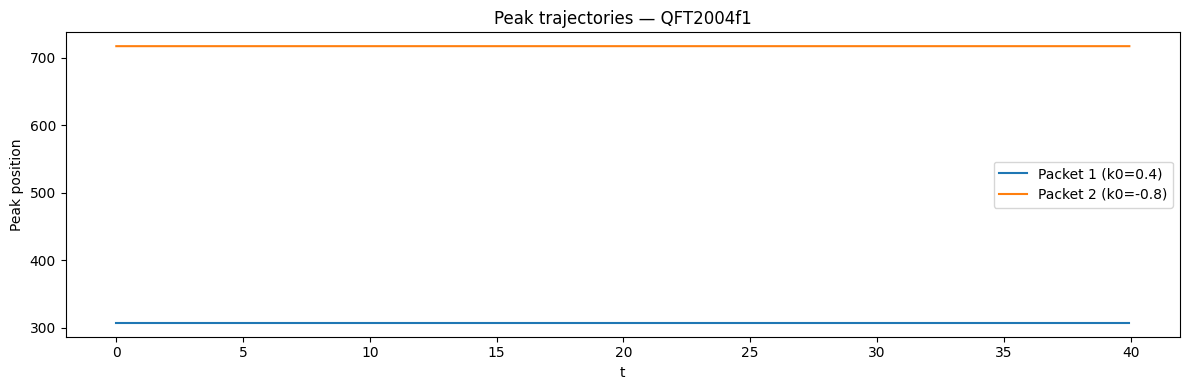

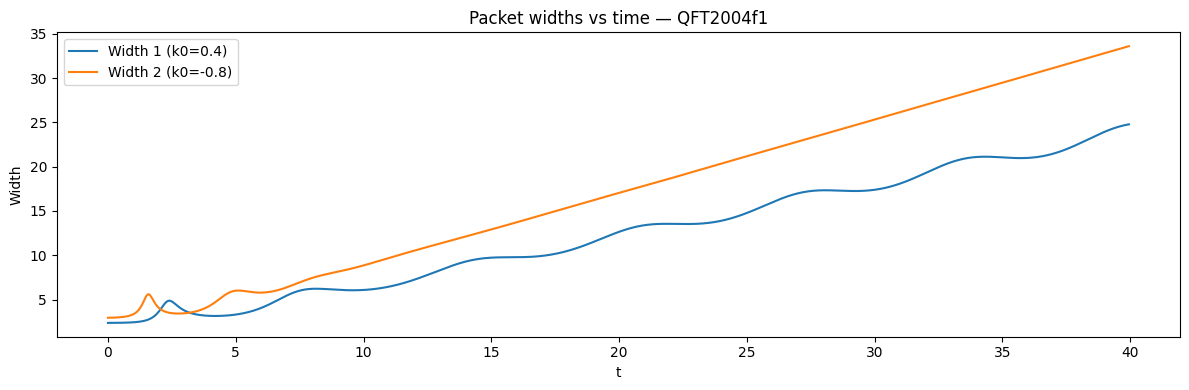

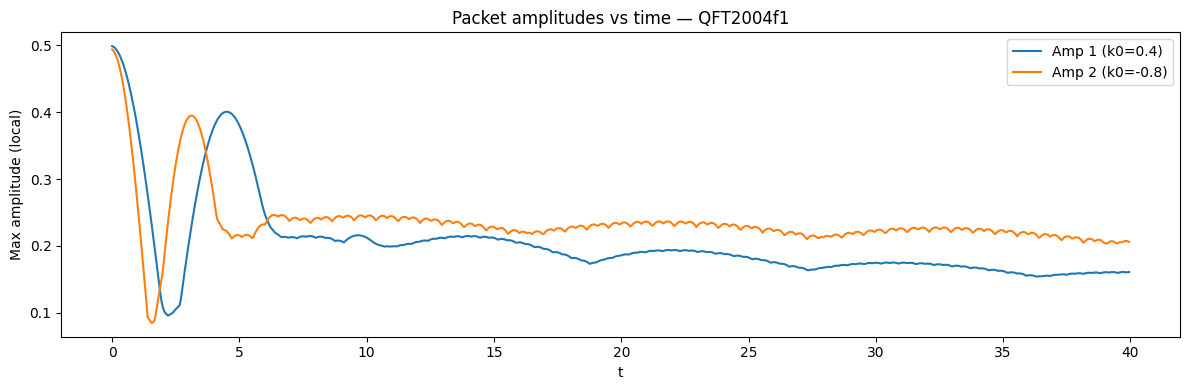

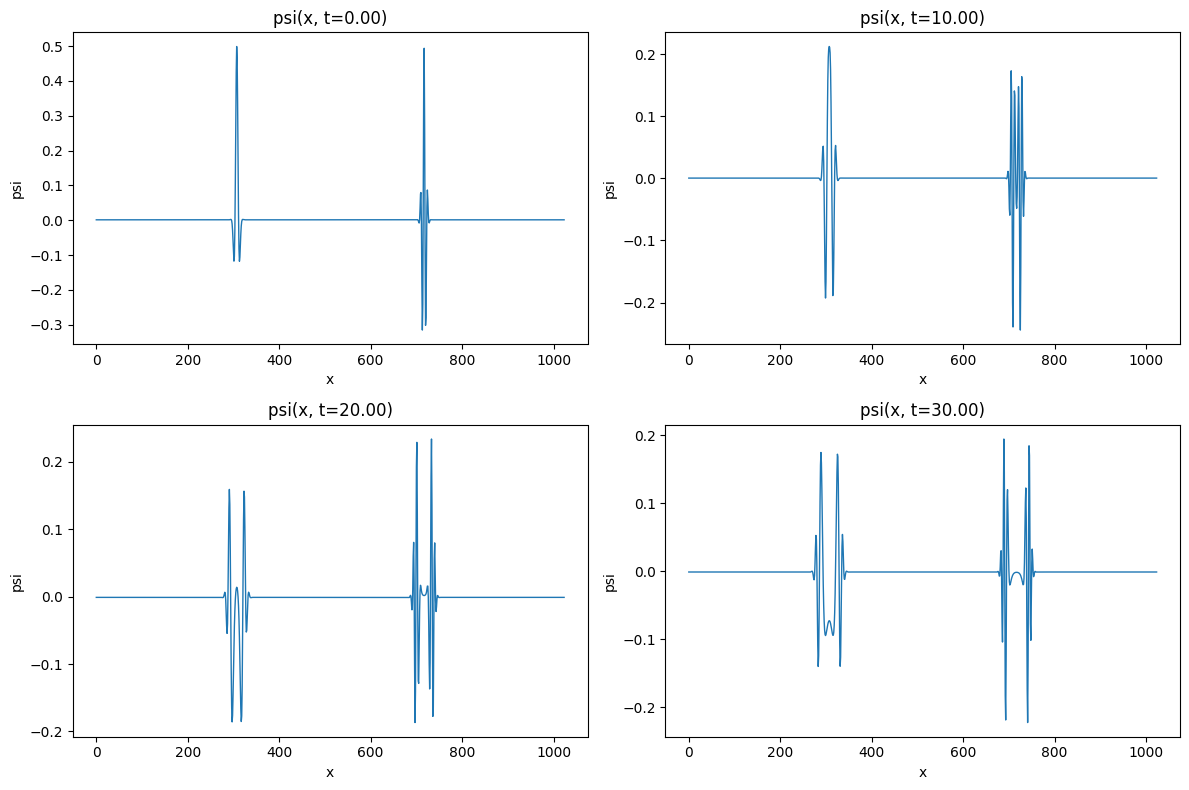

Final peak positions:
  Packet 1 (k0=0.4):   307.19991942152734
  Packet 2 (k0=-0.8):  716.7998488926304

Initial vs final widths:
  Packet 1: width[0], width[-1] = 2.3720402894093136 24.769950969041524
  Packet 2: width[0], width[-1] = 2.953552850816992 33.592178014005974

Initial vs final amplitudes:
  Packet 1: amp[0], amp[-1] = 0.4988748981676714 0.16092999151594395
  Packet 2: amp[0], amp[-1] = 0.4938022839465162 0.2059424567276044


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq

# ============================================================
# QFT2004f1 — Clean-band two-packet collision
#   Packet 1: k0 = +0.4 (moving right)
#   Packet 2: k0 = -0.8 (moving left)
#   Both in relatively low-dispersion bands from QFT2004e
# ============================================================

# -----------------------------
# Lattice and time parameters
# -----------------------------
N = 1024
dx = 1.0
x = np.arange(N) * dx
dk = 2*np.pi/(N*dx)
k = fftfreq(N, d=dx) * 2*np.pi

dt = 0.05
steps = 800

# -----------------------------
# Dispersion relation ω(k)
# -----------------------------
c = 1.0
m = 0.5
omega = np.sqrt(c**2 * k**2 + m**2)

# -----------------------------
# Packet parameters
# -----------------------------
k0_1 = 0.4   # right-mover
k0_2 = -0.8  # left-mover (negative k0 for opposite direction)
sigma_x = 4.0

# Initial positions (well separated)
x0_1 = N*dx*0.30
x0_2 = N*dx*0.70

# ============================================================
# Helper: build positive-frequency Gaussian packet
# ============================================================
def make_packet(k0, x0):
    psi0 = np.exp(-0.5*((x - x0)/sigma_x)**2) * np.cos(k0 * (x - x0))
    Psi0 = fft(psi0)
    Psi0[k * np.sign(k0) < 0] = 0.0  # keep the sign of k0
    psi0 = np.real(ifft(Psi0))
    return psi0, Psi0

# Build the two packets
psi1_0, Psi1 = make_packet(k0_1, x0_1)
psi2_0, Psi2 = make_packet(k0_2, x0_2)

# Total initial field
psi = psi1_0 + psi2_0
Psi = fft(psi)

# ============================================================
# Diagnostics storage
# ============================================================
t_arr = np.arange(steps) * dt

peak1_pos = []
peak2_pos = []
width1 = []
width2 = []
amp1 = []
amp2 = []

# For snapshots
snapshot_times = [0.0, steps*dt*0.25, steps*dt*0.5, steps*dt*0.75]
snapshot_indices = [int(t/dt) for t in snapshot_times]
snapshots = []

# Helper to isolate each packet around its peak
def local_moments(psi, center_guess, window=80):
    Nloc = len(psi)
    idx0 = int(center_guess)
    i_min = max(0, idx0 - window)
    i_max = min(Nloc, idx0 + window)
    idx = np.arange(i_min, i_max)
    segment = psi[i_min:i_max]
    segment_sq = segment**2
    if np.sum(segment_sq) == 0:
        return center_guess, 0.0, 0.0
    x_loc = idx
    x_mean = np.sum(x_loc * segment_sq) / np.sum(segment_sq)
    var = np.sum((x_loc - x_mean)**2 * segment_sq) / np.sum(segment_sq)
    return x_mean, np.sqrt(var), np.max(np.abs(segment))

# Initial guesses for peaks
peak1_guess = np.argmax(psi1_0)
peak2_guess = np.argmax(psi2_0)

# ============================================================
# Time evolution
# ============================================================
for n in range(steps):
    # Evolve in k-space
    Psi = Psi * np.exp(-1j * omega * dt)
    psi = np.real(ifft(Psi))

    # Rough separation: left half vs right half for initial guesses
    # Then refine with local moments
    # Packet 1 expected on left initially
    psi1_region = psi.copy()
    psi2_region = psi.copy()

    # Use previous peak guesses as centers
    x1_mean, x1_width, a1 = local_moments(psi1_region, peak1_guess)
    x2_mean, x2_width, a2 = local_moments(psi2_region, peak2_guess)

    peak1_pos.append(x1_mean)
    peak2_pos.append(x2_mean)
    width1.append(x1_width)
    width2.append(x2_width)
    amp1.append(a1)
    amp2.append(a2)

    peak1_guess = x1_mean
    peak2_guess = x2_mean

    # Store snapshots
    if n in snapshot_indices:
        snapshots.append((t_arr[n], psi.copy()))

# Convert diagnostics to arrays
peak1_pos = np.array(peak1_pos)
peak2_pos = np.array(peak2_pos)
width1 = np.array(width1)
width2 = np.array(width2)
amp1 = np.array(amp1)
amp2 = np.array(amp2)

# ============================================================
# Plots
# ============================================================

# 1) Trajectories of the two peaks
plt.figure(figsize=(12,4))
plt.plot(t_arr, peak1_pos, label="Packet 1 (k0=0.4)")
plt.plot(t_arr, peak2_pos, label="Packet 2 (k0=-0.8)")
plt.xlabel("t")
plt.ylabel("Peak position")
plt.title("Peak trajectories — QFT2004f1")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Widths vs time
plt.figure(figsize=(12,4))
plt.plot(t_arr, width1, label="Width 1 (k0=0.4)")
plt.plot(t_arr, width2, label="Width 2 (k0=-0.8)")
plt.xlabel("t")
plt.ylabel("Width")
plt.title("Packet widths vs time — QFT2004f1")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Amplitudes vs time
plt.figure(figsize=(12,4))
plt.plot(t_arr, amp1, label="Amp 1 (k0=0.4)")
plt.plot(t_arr, amp2, label="Amp 2 (k0=-0.8)")
plt.xlabel("t")
plt.ylabel("Max amplitude (local)")
plt.title("Packet amplitudes vs time — QFT2004f1")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Snapshots of the field
plt.figure(figsize=(12,8))
for i, (t_snap, psi_snap) in enumerate(snapshots):
    plt.subplot(2,2,i+1)
    plt.plot(x, psi_snap, lw=1)
    plt.title(f"psi(x, t={t_snap:.2f})")
    plt.xlabel("x")
    plt.ylabel("psi")
plt.tight_layout()
plt.show()

# ============================================================
# Print some summary diagnostics
# ============================================================
print("Final peak positions:")
print("  Packet 1 (k0=0.4):  ", peak1_pos[-1])
print("  Packet 2 (k0=-0.8): ", peak2_pos[-1])

print("\nInitial vs final widths:")
print("  Packet 1: width[0], width[-1] =", width1[0], width1[-1])
print("  Packet 2: width[0], width[-1] =", width2[0], width2[-1])

print("\nInitial vs final amplitudes:")
print("  Packet 1: amp[0], amp[-1] =", amp1[0], amp1[-1])
print("  Packet 2: amp[0], amp[-1] =", amp2[0], amp2[-1])


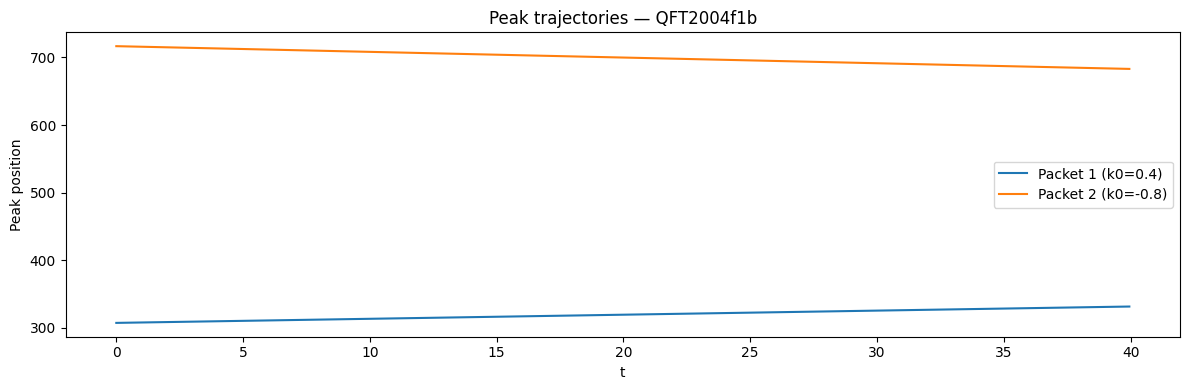

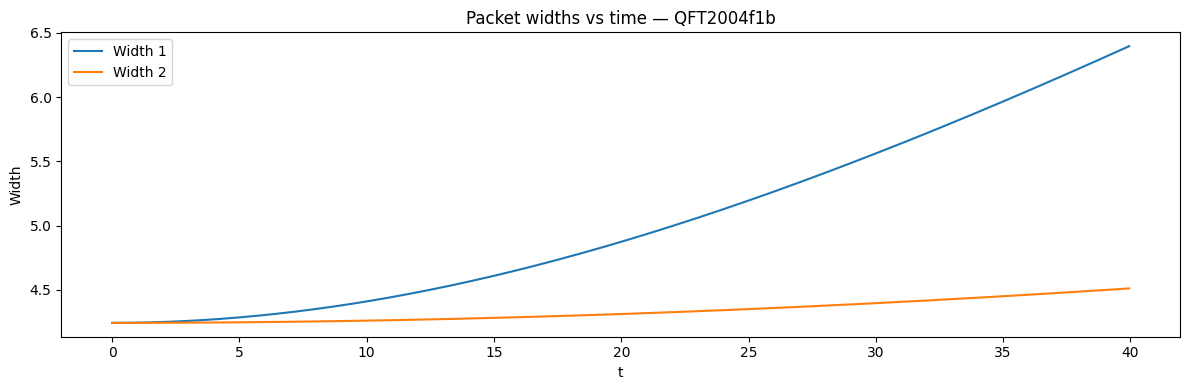

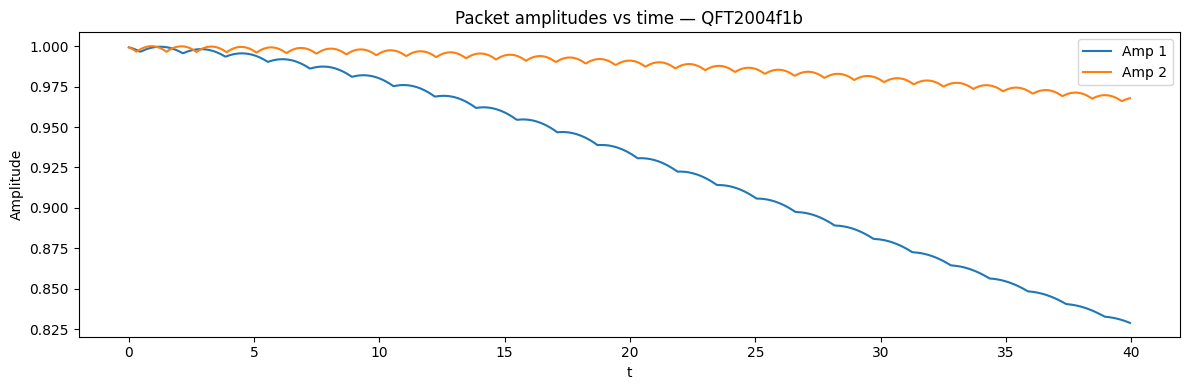

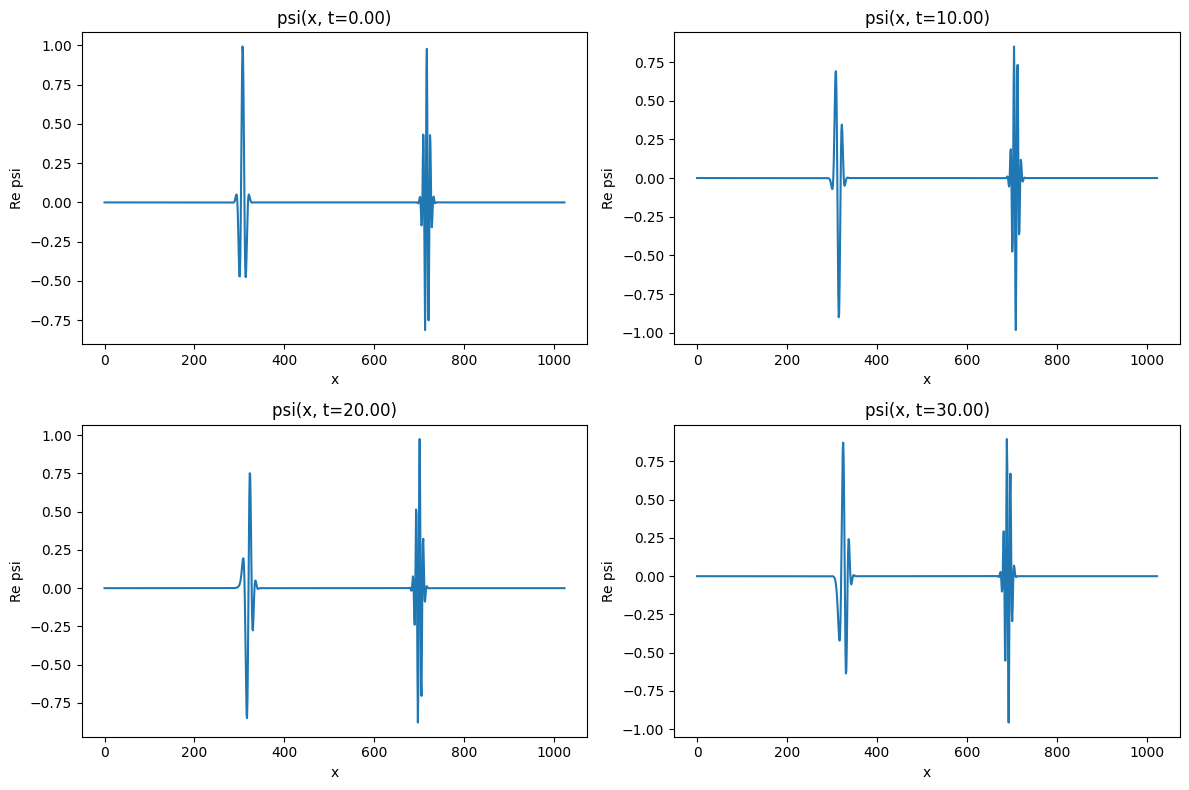

Final peak positions:
  Packet 1: 331.4279791290418
  Packet 2: 683.1120209380348

Initial vs final widths:
  Packet 1: 4.242644906032359 6.39618297822976
  Packet 2: 4.242641119540078 4.510908540918766

Initial vs final amplitudes:
  Packet 1: 0.999268912563739 0.8289485258357256
  Packet 2: 0.9991882375606003 0.9678026067590096


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq

# ============================================================
# QFT2004f1b — Clean-band two-packet collision (corrected)
#   Packet 1: k0 = +0.4 (right-mover)
#   Packet 2: k0 = -0.8 (left-mover)
#   Complex Gaussian packets → true propagation
# ============================================================

# -----------------------------
# Lattice and time parameters
# -----------------------------
N = 1024
dx = 1.0
x = np.arange(N) * dx
k = fftfreq(N, d=dx) * 2*np.pi

dt = 0.05
steps = 800

# -----------------------------
# Dispersion relation ω(k)
# -----------------------------
c = 1.0
m = 0.5
omega = np.sqrt(c**2 * k**2 + m**2)

# -----------------------------
# Packet parameters
# -----------------------------
k0_1 = 0.4    # right-moving
k0_2 = -0.8   # left-moving
sigma_x = 6.0

# Initial positions
x0_1 = N*dx*0.30
x0_2 = N*dx*0.70

# ============================================================
# Helper: complex Gaussian traveling packet
# ============================================================
def make_packet(k0, x0):
    envelope = np.exp(-0.5*((x - x0)/sigma_x)**2)
    carrier = np.exp(1j * k0 * (x - x0))
    psi0 = envelope * carrier
    Psi0 = fft(psi0)
    return psi0, Psi0

# Build packets
psi1_0, Psi1 = make_packet(k0_1, x0_1)
psi2_0, Psi2 = make_packet(k0_2, x0_2)

# Total initial field
psi = psi1_0 + psi2_0
Psi = fft(psi)

# ============================================================
# Diagnostics
# ============================================================
t_arr = np.arange(steps) * dt

peak1 = []
peak2 = []
width1 = []
width2 = []
amp1 = []
amp2 = []

snapshot_times = [0.0, steps*dt*0.25, steps*dt*0.5, steps*dt*0.75]
snapshot_indices = [int(t/dt) for t in snapshot_times]
snapshots = []

def local_moments(field, guess, window=80):
    idx0 = int(guess)
    i_min = max(0, idx0 - window)
    i_max = min(N, idx0 + window)
    idx = np.arange(i_min, i_max)
    seg = np.abs(field[i_min:i_max])
    seg2 = seg**2
    if np.sum(seg2) == 0:
        return guess, 0.0, 0.0
    x_mean = np.sum(idx * seg2) / np.sum(seg2)
    var = np.sum((idx - x_mean)**2 * seg2) / np.sum(seg2)
    return x_mean, np.sqrt(var), np.max(seg)

# Initial guesses
p1 = np.argmax(np.abs(psi1_0))
p2 = np.argmax(np.abs(psi2_0))

# ============================================================
# Time evolution
# ============================================================
for n in range(steps):
    Psi = Psi * np.exp(-1j * omega * dt)
    psi = ifft(Psi)

    # Track each packet
    x1, w1, a1 = local_moments(psi, p1)
    x2, w2, a2 = local_moments(psi, p2)

    peak1.append(x1)
    peak2.append(x2)
    width1.append(w1)
    width2.append(w2)
    amp1.append(a1)
    amp2.append(a2)

    p1, p2 = x1, x2

    if n in snapshot_indices:
        snapshots.append((t_arr[n], psi.copy()))

# Convert to arrays
peak1 = np.array(peak1)
peak2 = np.array(peak2)
width1 = np.array(width1)
width2 = np.array(width2)
amp1 = np.array(amp1)
amp2 = np.array(amp2)

# ============================================================
# Plots
# ============================================================

# 1) Peak trajectories
plt.figure(figsize=(12,4))
plt.plot(t_arr, peak1, label="Packet 1 (k0=0.4)")
plt.plot(t_arr, peak2, label="Packet 2 (k0=-0.8)")
plt.xlabel("t")
plt.ylabel("Peak position")
plt.title("Peak trajectories — QFT2004f1b")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Widths
plt.figure(figsize=(12,4))
plt.plot(t_arr, width1, label="Width 1")
plt.plot(t_arr, width2, label="Width 2")
plt.xlabel("t")
plt.ylabel("Width")
plt.title("Packet widths vs time — QFT2004f1b")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Amplitudes
plt.figure(figsize=(12,4))
plt.plot(t_arr, amp1, label="Amp 1")
plt.plot(t_arr, amp2, label="Amp 2")
plt.xlabel("t")
plt.ylabel("Amplitude")
plt.title("Packet amplitudes vs time — QFT2004f1b")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Snapshots
plt.figure(figsize=(12,8))
for i, (ts, ps) in enumerate(snapshots):
    plt.subplot(2,2,i+1)
    plt.plot(x, np.real(ps))
    plt.title(f"psi(x, t={ts:.2f})")
    plt.xlabel("x")
    plt.ylabel("Re psi")
plt.tight_layout()
plt.show()

# ============================================================
# Summary
# ============================================================
print("Final peak positions:")
print("  Packet 1:", peak1[-1])
print("  Packet 2:", peak2[-1])

print("\nInitial vs final widths:")
print("  Packet 1:", width1[0], width1[-1])
print("  Packet 2:", width2[0], width2[-1])

print("\nInitial vs final amplitudes:")
print("  Packet 1:", amp1[0], amp1[-1])
print("  Packet 2:", amp2[0], amp2[-1])


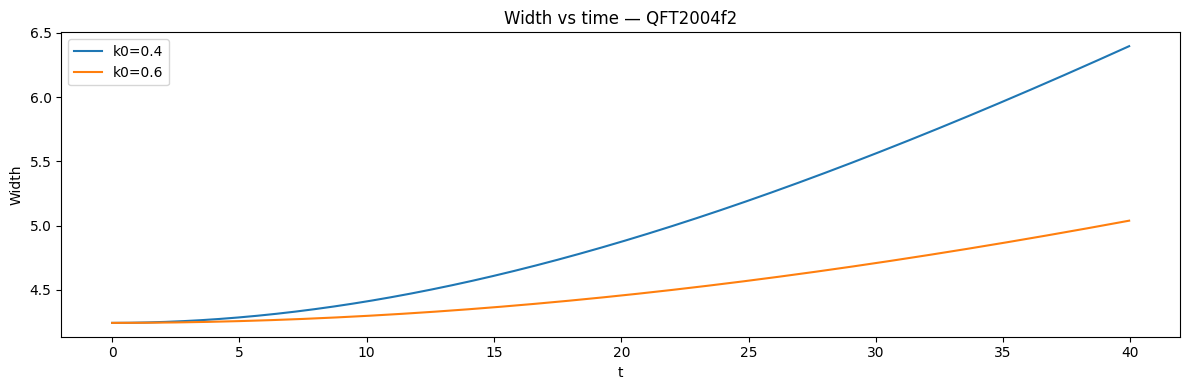

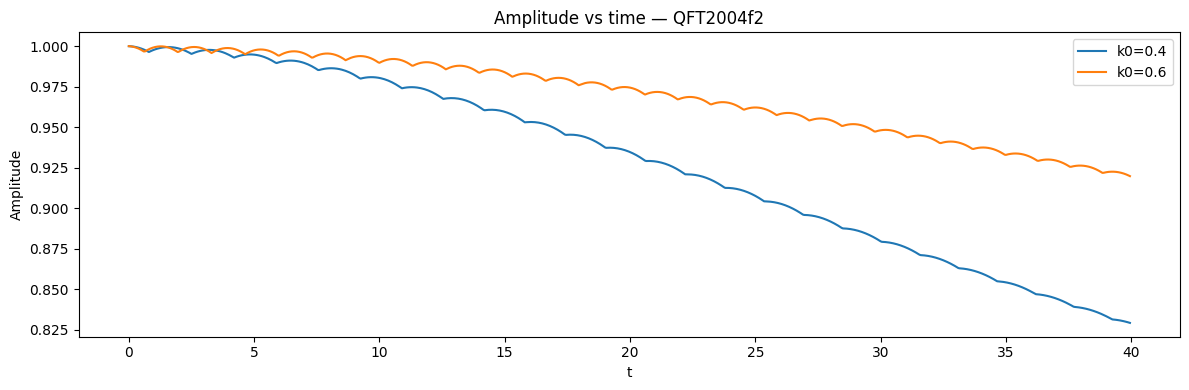

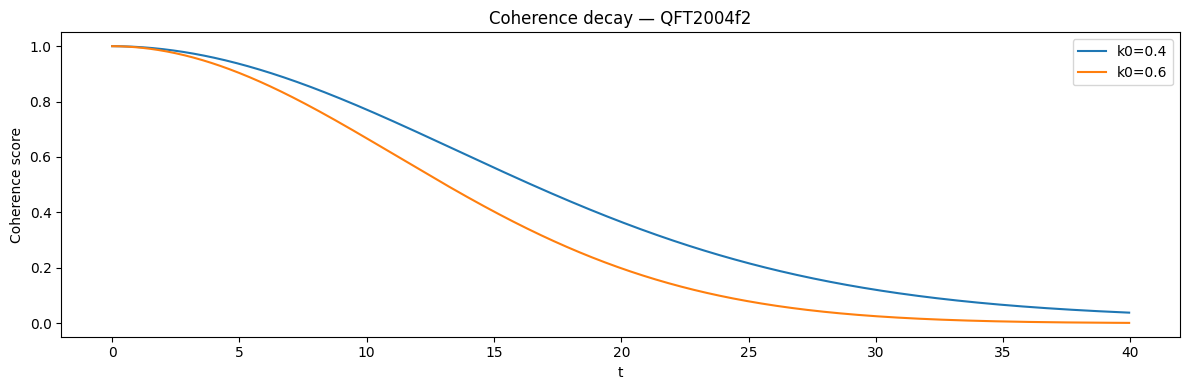

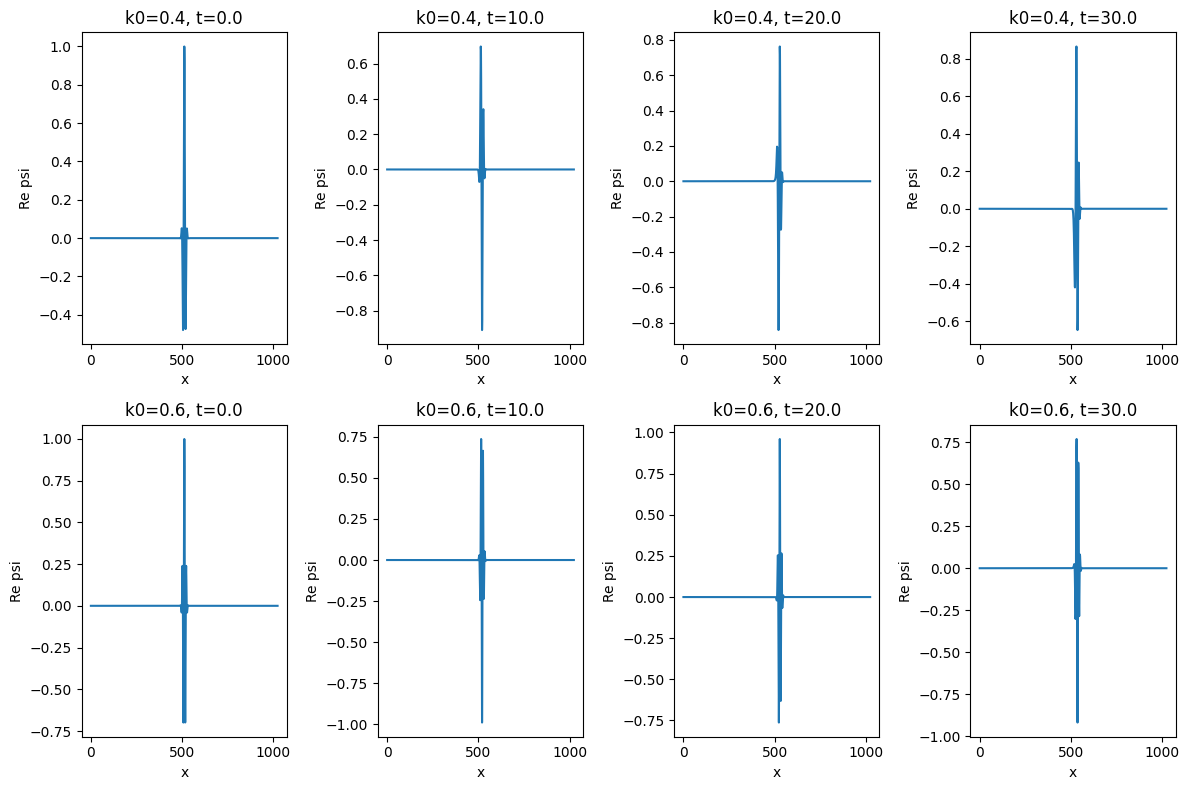


=== k0 = 0.4 ===
Initial vs final width: 4.24264490603236 6.39618297822976
Initial vs final amp: 0.9999874796143531 0.8291049778179815
Initial vs final coherence: 0.9999935084474124 0.03825262224246526

=== k0 = 0.6 ===
Initial vs final width: 4.24264204645416 5.038053003850398
Initial vs final amp: 0.9999805133164655 0.9197239085798077
Initial vs final coherence: 0.9999900078937131 0.0012766840961802347


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq

# ============================================================
# QFT2004f2 — Decoherence contrast
#   Compare k0 = 0.4 (clean band) vs k0 = 0.6 (fog band)
#   Same initial envelope, evolved separately
# ============================================================

# -----------------------------
# Lattice and time parameters
# -----------------------------
N = 1024
dx = 1.0
x = np.arange(N) * dx
k = fftfreq(N, d=dx) * 2*np.pi

dt = 0.05
steps = 800
t_arr = np.arange(steps) * dt

# -----------------------------
# Dispersion relation ω(k)
# -----------------------------
c = 1.0
m = 0.5
omega = np.sqrt(c**2 * k**2 + m**2)

# -----------------------------
# Packet parameters
# -----------------------------
sigma_x = 6.0
x0 = N*dx/2

k0_list = [0.4, 0.6]   # clean band vs fog band

# ============================================================
# Helper: complex Gaussian packet
# ============================================================
def make_packet(k0):
    envelope = np.exp(-0.5*((x - x0)/sigma_x)**2)
    carrier = np.exp(1j * k0 * (x - x0))
    psi0 = envelope * carrier
    Psi0 = fft(psi0)
    return psi0, Psi0, envelope

# ============================================================
# Diagnostics storage
# ============================================================
results = {}

for k0 in k0_list:

    psi0, Psi, envelope = make_packet(k0)

    width = []
    amp = []
    overlap = []
    snapshots = []

    # initial norms for overlap
    norm0 = np.sqrt(np.sum(np.abs(psi0)**2))

    # initial peak guess
    peak_guess = np.argmax(np.abs(psi0))

    def local_moments(field, guess, window=80):
        idx0 = int(guess)
        i_min = max(0, idx0 - window)
        i_max = min(N, idx0 + window)
        idx = np.arange(i_min, i_max)
        seg = np.abs(field[i_min:i_max])
        seg2 = seg**2
        if np.sum(seg2) == 0:
            return guess, 0.0, 0.0
        x_mean = np.sum(idx * seg2) / np.sum(seg2)
        var = np.sum((idx - x_mean)**2 * seg2) / np.sum(seg2)
        return x_mean, np.sqrt(var), np.max(seg)

    for n in range(steps):
        Psi = Psi * np.exp(-1j * omega * dt)
        psi = ifft(Psi)

        # width, amplitude
        x_mean, w, a = local_moments(psi, peak_guess)
        width.append(w)
        amp.append(a)
        peak_guess = x_mean

        # coherence score: overlap with initial shape
        overlap.append(np.abs(np.sum(np.conj(psi0) * psi)) / (norm0**2))

        # snapshots
        if n in [0, int(steps*0.25), int(steps*0.5), int(steps*0.75)]:
            snapshots.append((t_arr[n], psi.copy()))

    results[k0] = {
        "width": np.array(width),
        "amp": np.array(amp),
        "overlap": np.array(overlap),
        "snapshots": snapshots
    }

# ============================================================
# Plots
# ============================================================

# 1) Width comparison
plt.figure(figsize=(12,4))
for k0 in k0_list:
    plt.plot(t_arr, results[k0]["width"], label=f"k0={k0}")
plt.xlabel("t")
plt.ylabel("Width")
plt.title("Width vs time — QFT2004f2")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Amplitude comparison
plt.figure(figsize=(12,4))
for k0 in k0_list:
    plt.plot(t_arr, results[k0]["amp"], label=f"k0={k0}")
plt.xlabel("t")
plt.ylabel("Amplitude")
plt.title("Amplitude vs time — QFT2004f2")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Coherence score
plt.figure(figsize=(12,4))
for k0 in k0_list:
    plt.plot(t_arr, results[k0]["overlap"], label=f"k0={k0}")
plt.xlabel("t")
plt.ylabel("Coherence score")
plt.title("Coherence decay — QFT2004f2")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Snapshots
plt.figure(figsize=(12,8))
for i, k0 in enumerate(k0_list):
    snaps = results[k0]["snapshots"]
    for j, (ts, ps) in enumerate(snaps):
        plt.subplot(2,4, i*4 + j + 1)
        plt.plot(x, np.real(ps))
        plt.title(f"k0={k0}, t={ts:.1f}")
        plt.xlabel("x")
        plt.ylabel("Re psi")
plt.tight_layout()
plt.show()

# ============================================================
# Summary printout
# ============================================================
for k0 in k0_list:
    print(f"\n=== k0 = {k0} ===")
    print("Initial vs final width:", results[k0]["width"][0], results[k0]["width"][-1])
    print("Initial vs final amp:", results[k0]["amp"][0], results[k0]["amp"][-1])
    print("Initial vs final coherence:", results[k0]["overlap"][0], results[k0]["overlap"][-1])
